# Superstore Sales Data Analysis

A Python data science notebook for cleaning, exploring, visualizing, and preparing Superstore sales data for business analytics.


## Libraries

In [1]:
import pandas as pd  # Used for data manipulation and analysis
import numpy as np  # Provides numerical operations and array handling
import matplotlib.pyplot as plt  # Used for creating static visualizations (charts & plots)
import seaborn as sns  # Enhances Matplotlib with advanced statistical visualizations
from rich.console import Console  # Enables styled console output (colored text, tables)
from rich.text import Text  # Allows rich-formatted text (bold, colored, styled) in the console


## Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv("superstore_dataset.csv")
# Display first few rows
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


## Data Cleaning and Preparation
- Analysis starts only after successful completion of data cleaning. This step involves:
- Handling missing values
- Standardizing column names
- Removing unnecessary columns
- The data cleaning procedure includes maintaining uniformity in data types.

=- The data cleaning process enables accurate results and avoidance of computational mistakes.


In [3]:
# Checking for missing values in the dataset
missing_values = df.isnull().sum()
missing_values[missing_values > 0]  # Show only columns with missing values


Series([], dtype: int64)

In [4]:
# Dropping unnecessary columns
df.drop(columns=['zip', 'country'], inplace=True)

# Display updated columns
df.columns


Index(['order_id', 'order_date', 'ship_date', 'customer', 'manufactory',
       'product_name', 'segment', 'category', 'subcategory', 'region', 'city',
       'state', 'discount', 'profit', 'quantity', 'sales', 'profit_margin'],
      dtype='object')

In [5]:
# Convert date columns to datetime
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

# Confirm changes
print(df.dtypes)


order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
customer                 object
manufactory              object
product_name             object
segment                  object
category                 object
subcategory              object
region                   object
city                     object
state                    object
discount                float64
profit                  float64
quantity                  int64
sales                   float64
profit_margin           float64
dtype: object


In [6]:
# Filling missing values for numerical columns with the median
df['profit'] = df['profit'].fillna(df['profit'].median())
df['discount'] = df['discount'].fillna(df['discount'].median())

In [7]:
# Dropping rows with missing categorical values (customer, product_name)
df.dropna(subset=['product_name'], inplace=True)

df.fillna({'customer': 'unknown'}, inplace=True)

# Confirming that missing values are handled
df.isnull().sum()


order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
city             0
state            0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64

In [57]:
# Function to remove outliers using the Interquartile Range (IQR) method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply outlier removal to relevant numerical columns
for col in ['discount', 'profit', 'quantity', 'sales']:
    df = remove_outliers(df, col)

In [9]:
# Convert string columns to lowercase and remove extra spaces for consistency
string_columns = ['customer', 'manufactory', 'product_name', 'segment', 
                  'category', 'subcategory', 'region', 'city', 'state']
for col in string_columns:
    df[col] = df[col].str.lower().str.strip()

In [10]:
# Remove duplicate rows to avoid redundant data
df.drop_duplicates(inplace=True)

In [11]:
# Display dataset info
df.info()

# Preview first few rows again
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6777 entries, 0 to 9993
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       6777 non-null   object        
 1   order_date     6777 non-null   datetime64[ns]
 2   ship_date      6777 non-null   datetime64[ns]
 3   customer       6777 non-null   object        
 4   manufactory    6777 non-null   object        
 5   product_name   6777 non-null   object        
 6   segment        6777 non-null   object        
 7   category       6777 non-null   object        
 8   subcategory    6777 non-null   object        
 9   region         6777 non-null   object        
 10  city           6777 non-null   object        
 11  state          6777 non-null   object        
 12  discount       6777 non-null   float64       
 13  profit         6777 non-null   float64       
 14  quantity       6777 non-null   int64         
 15  sales          6777 non-nu

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,city,state,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,2019-01-03,2019-01-07,darren powers,message book,"message book, wirebound, four 5 1/2"" x 4"" form...",consumer,office supplies,paper,central,houston,texas,0.2,5.5512,2,16.448,0.3375
2,US-2020-112326,2019-01-04,2019-01-08,phillina ober,avery,avery 508,home office,office supplies,labels,central,naperville,illinois,0.2,4.2717,3,11.784,0.3625
4,US-2020-141817,2019-01-05,2019-01-12,mick brown,avery,avery hi-liter everbold pen style fluorescent ...,consumer,office supplies,art,east,philadelphia,pennsylvania,0.2,4.8840,3,19.536,0.2500
5,US-2020-106054,2019-01-06,2019-01-07,jack o'briant,dixon,"dixon prang watercolor pencils, 10-color set w...",corporate,office supplies,art,south,athens,georgia,0.0,5.2398,3,12.780,0.4100
6,US-2020-130813,2019-01-06,2019-01-08,lycoris saunders,xerox,xerox 225,consumer,office supplies,paper,west,los angeles,california,0.0,9.3312,3,19.440,0.4800


# - Verify it's Cleaned 

In [12]:
df.to_csv("cleaned_data.csv", index=False)


In [13]:
print(df.columns)


Index(['order_id', 'order_date', 'ship_date', 'customer', 'manufactory',
       'product_name', 'segment', 'category', 'subcategory', 'region', 'city',
       'state', 'discount', 'profit', 'quantity', 'sales', 'profit_margin'],
      dtype='object')


In [14]:
print(df.isnull().sum())


order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
city             0
state            0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64


In [15]:
print(df.columns)
print(df.head())


Index(['order_id', 'order_date', 'ship_date', 'customer', 'manufactory',
       'product_name', 'segment', 'category', 'subcategory', 'region', 'city',
       'state', 'discount', 'profit', 'quantity', 'sales', 'profit_margin'],
      dtype='object')
         order_id order_date  ship_date          customer   manufactory  \
0  US-2020-103800 2019-01-03 2019-01-07     darren powers  message book   
2  US-2020-112326 2019-01-04 2019-01-08     phillina ober         avery   
4  US-2020-141817 2019-01-05 2019-01-12        mick brown         avery   
5  US-2020-106054 2019-01-06 2019-01-07     jack o'briant         dixon   
6  US-2020-130813 2019-01-06 2019-01-08  lycoris saunders         xerox   

                                        product_name      segment  \
0  message book, wirebound, four 5 1/2" x 4" form...     consumer   
2                                          avery 508  home office   
4  avery hi-liter everbold pen style fluorescent ...     consumer   
5  dixon prang waterco

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6777 entries, 0 to 9993
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       6777 non-null   object        
 1   order_date     6777 non-null   datetime64[ns]
 2   ship_date      6777 non-null   datetime64[ns]
 3   customer       6777 non-null   object        
 4   manufactory    6777 non-null   object        
 5   product_name   6777 non-null   object        
 6   segment        6777 non-null   object        
 7   category       6777 non-null   object        
 8   subcategory    6777 non-null   object        
 9   region         6777 non-null   object        
 10  city           6777 non-null   object        
 11  state          6777 non-null   object        
 12  discount       6777 non-null   float64       
 13  profit         6777 non-null   float64       
 14  quantity       6777 non-null   int64         
 15  sales          6777 non-nu

# 📝 Questions: 

## Question 1: Which customer has made the highest total purchases?

In [17]:
# Group by customer and sum the sales
top_customer = df.groupby("customer")["sales"].sum().idxmax()
top_sales = df.groupby("customer")["sales"].sum().max()


print(f"The customer with the highest total purchases is '{top_customer}' with total sales of {top_sales:.2f}.")

The customer with the highest total purchases is 'paul prost' with total sales of 1914.63.


## Question 2: What percentage of orders result in a loss (negative profit)?

In [18]:
# Calculate total orders and loss-making orders
total_orders = len(df)
loss_orders = len(df[df["profit"] < 0])

# Calculate percentage
loss_percentage = (loss_orders / total_orders) * 100
print(f"Percentage of orders that resulted in a loss: {loss_percentage:.2f}%")


Percentage of orders that resulted in a loss: 7.22%


 ## Question 3: What is the most frequently purchased product?

In [19]:
# Find the most frequently purchased product
most_frequent_product = df["product_name"].value_counts().idxmax()
product_count = df["product_name"].value_counts().max()

# Display result
print(f"The most frequently purchased product is '{most_frequent_product}' with {product_count} purchases.")


The most frequently purchased product is 'staple envelope' with 47 purchases.


## Question 4: Which product category has the highest average profit per order?

In [20]:
# Group by category and compute average profit per order
highest_avg_profit_category = df.groupby("category")["profit"].mean().idxmax()
highest_avg_profit = df.groupby("category")["profit"].mean().max()

# Display result
print(f"The product category with the highest average profit per order is '{highest_avg_profit_category}' with an average profit of {highest_avg_profit:.2f}.")


The product category with the highest average profit per order is 'technology' with an average profit of 15.52.


##  Question 5: What is the average shipping time for orders?

In [21]:
# Calculate shipping time
df["shipping_time"] = (df["ship_date"] - df["order_date"]).dt.days

# Compute average shipping time
average_shipping_time = df["shipping_time"].mean()

# Display result
print(f"The average shipping time for orders is {average_shipping_time:.2f} days.")


The average shipping time for orders is 3.96 days.


## Question 6: What percentage of orders received a discount of 20% or more?

In [22]:
# Count orders with discount ≥ 20%
discounted_orders = len(df[df["discount"] >= 0.20])

# Compute percentage
discount_percentage = (discounted_orders / total_orders) * 100

# Display result
print(f"Percentage of orders with a discount of 20% or more: {discount_percentage:.2f}%")


Percentage of orders with a discount of 20% or more: 44.41%


## Question 7: What is the average number of products per order?

In [23]:
# Compute average quantity per order
average_products_per_order = df["quantity"].mean()

# Display result
print(f"The average number of products per order is {average_products_per_order:.2f}.")


The average number of products per order is 3.39.


## Question 8: What is the total number of orders placed in each year?

In [24]:
# Extract year and count unique orders per year
df["year"] = df["order_date"].dt.year
orders_per_year = df.groupby("year")["order_id"].nunique()

# Display result
print(orders_per_year)


year
2019     781
2020     845
2021    1057
2022    1368
Name: order_id, dtype: int64


## Question 9: Which city has the lowest total sales?

In [25]:
# Group by city and find the city with the lowest total sales
lowest_sales_city = df.groupby("city")["sales"].sum().idxmin()
lowest_sales_value = df.groupby("city")["sales"].sum().min()

# Display result
print(f"The city with the lowest total sales is '{lowest_sales_city}' with total sales of {lowest_sales_value:.2f}.")


The city with the lowest total sales is 'jupiter' with total sales of 2.06.


 ## Question 10: Which category of product has the highest average profit per order?

In [26]:
# Group by category and compute average profit per order
highest_avg_profit_category = df.groupby("category")["profit"].mean().idxmax()
highest_avg_profit = df.groupby("category")["profit"].mean().max()

# Display result
print(f"The product category with the highest average profit per order is '{highest_avg_profit_category}' with an average profit of {highest_avg_profit:.2f}.")


The product category with the highest average profit per order is 'technology' with an average profit of 15.52.


## Question 11: Which month has the highest total sales?

In [27]:
# Extract month
df["month"] = df["order_date"].dt.month

# Compute total sales per month
highest_sales_month = df.groupby("month")["sales"].sum().idxmax()
highest_sales_value = df.groupby("month")["sales"].sum().max()

# Display result
print(f"The month with the highest total sales is {highest_sales_month} with total sales of {highest_sales_value:.2f}.")


The month with the highest total sales is 12 with total sales of 58887.97.


## Question 12: Which manufactory makes the highest total sales?

In [28]:
# Group by manufactory and compute total sales
highest_sales_manufactory = df.groupby("manufactory")["sales"].sum().idxmax()
highest_sales_value = df.groupby("manufactory")["sales"].sum().max()

# Display result
print(f"The manufactory with the highest total sales is '{highest_sales_manufactory}' with total sales of {highest_sales_value:.2f}.")


The manufactory with the highest total sales is 'other' with total sales of 78757.96.


## Question 13: What is the total number of orders that shipped in each month?

In [29]:
# Extract month from ship_date
df["ship_month"] = df["ship_date"].dt.month

# Compute total shipped orders per month
orders_shipped_per_month = df.groupby("ship_month")["order_id"].nunique()

# Display result
print(orders_shipped_per_month)


ship_month
1     190
2     141
3     268
4     274
5     302
6     305
7     286
8     264
9     537
10    338
11    581
12    565
Name: order_id, dtype: int64


## 📈 Data Visualization & Insights


## Visualization 1: Top 10 Customers by Total Purchases

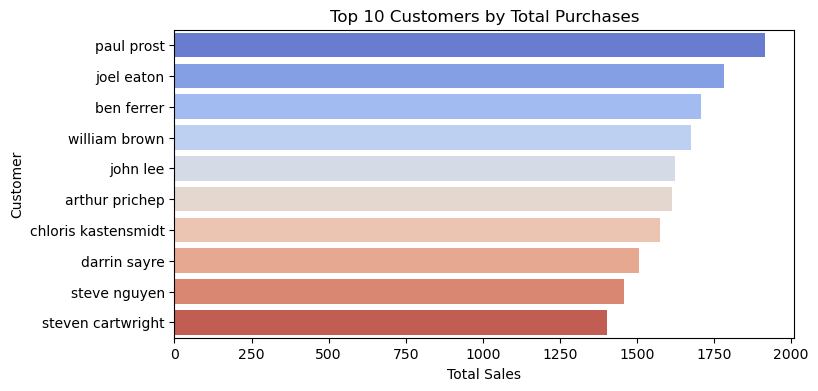

In [30]:
# Compute top 10 customers
top_10_customers = df.groupby("customer")["sales"].sum().nlargest(10)

# Plot bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x=top_10_customers.values, y=top_10_customers.index, hue=top_10_customers.index, palette="coolwarm", legend=False)
plt.xlabel("Total Sales")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Total Purchases")
plt.show()


## Visualization 2: Percentage of Orders That Result in a Loss

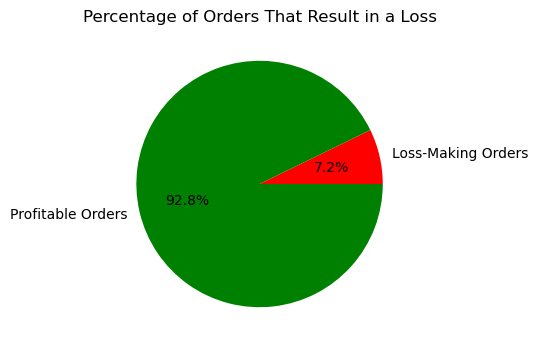

In [31]:
# Compute the number of loss-making orders
loss_orders = df[df["profit"] < 0].shape[0]  # Count rows where profit is negative

# Compute total number of orders
total_orders = df.shape[0]  # Total number of rows

# Compute loss-making and profitable orders
loss_counts = [loss_orders, total_orders - loss_orders]
labels = ["Loss-Making Orders", "Profitable Orders"]

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(loss_counts, labels=labels, autopct='%1.1f%%', colors=['red', 'green'])
plt.title("Percentage of Orders That Result in a Loss")
plt.show()


## Visualization 3: Most Frequently Purchased Products

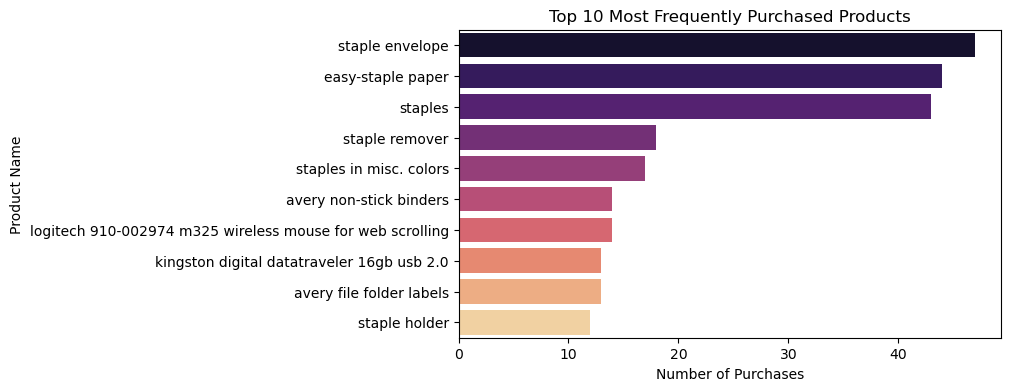

In [32]:
# Compute top 10 most frequently purchased products
top_10_products = df["product_name"].value_counts().nlargest(10)

# Plot bar chart
plt.figure(figsize=(7, 4))
sns.barplot(x=top_10_products.values, y=top_10_products.index, hue=top_10_products.index, palette="magma", legend=False)
plt.xlabel("Number of Purchases")
plt.ylabel("Product Name")
plt.title("Top 10 Most Frequently Purchased Products")
plt.show()


## Visualization 4: Profitability by Category

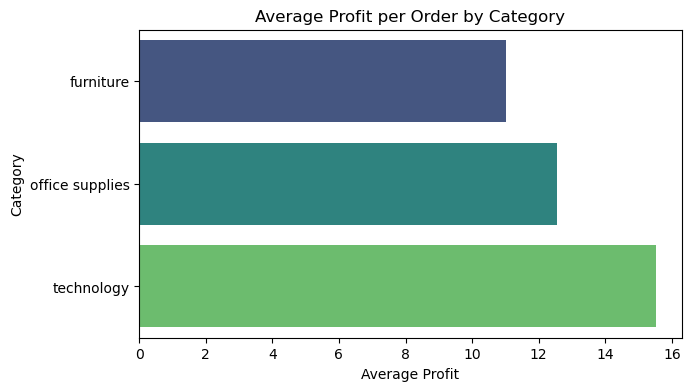

In [33]:
# Compute average profit per category
category_avg_profit = df.groupby("category")["profit"].mean().sort_values()

# Plot bar chart
plt.figure(figsize=(7, 4))
sns.barplot(x=category_avg_profit.values, y=category_avg_profit.index, hue=category_avg_profit.index, palette="viridis", legend=False)
plt.xlabel("Average Profit")
plt.ylabel("Category")
plt.title("Average Profit per Order by Category")
plt.show()


## Visualization 5: Average Shipping Time Per Order

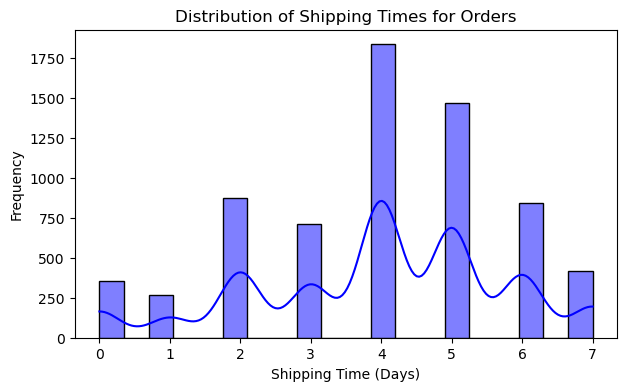

In [34]:
# Plot histogram of shipping time
plt.figure(figsize=(7, 4))
sns.histplot(df["shipping_time"], bins=20, kde=True, color="blue")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Frequency")
plt.title("Distribution of Shipping Times for Orders")
plt.show()


## Visualization 6: Percentage of Orders with a 20% or More Discount

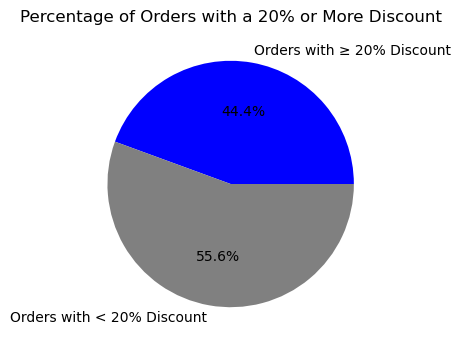

In [35]:
# Define the threshold for significant discount
discount_threshold = 0.2  # 20%
# Count orders with and without significant discount
discounted_orders = (df["discount"] >= discount_threshold).sum()
non_discounted_orders = (df["discount"] < discount_threshold).sum()
# Data for the pie chart
discount_counts = [discounted_orders, non_discounted_orders]
labels = ["Orders with ≥ 20% Discount", "Orders with < 20% Discount"]
# Plot the pie chart
plt.figure(figsize=(4, 4))
plt.pie(discount_counts, labels=labels, autopct='%1.1f%%', colors=['blue', 'gray'])
plt.title("Percentage of Orders with a 20% or More Discount")
plt.show()


## Visualization 7: Distribution of Number of Products per Order

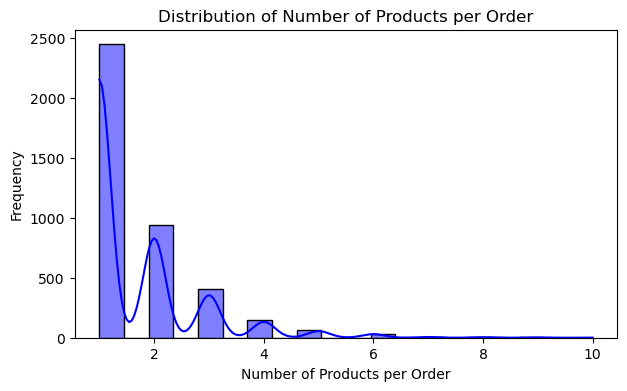

In [36]:
# Compute the number of products per order
products_per_order = df.groupby("order_id")["product_name"].count()

# Plot histogram
plt.figure(figsize=(7, 4))
sns.histplot(products_per_order, bins=20, kde=True, color="blue")
plt.xlabel("Number of Products per Order")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Products per Order")
plt.show()


## Visualization 8: Total Orders Per Year

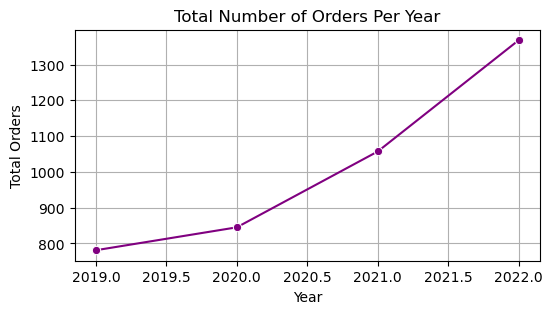

In [37]:
# Extract the year from the order date
df["year"] = df["order_date"].dt.year
# Compute total orders per year
orders_per_year = df.groupby("year")["order_id"].nunique()

# Plot total orders per year
plt.figure(figsize=(6, 3))
sns.lineplot(x=orders_per_year.index, y=orders_per_year.values, marker="o", color="purple")
plt.xlabel("Year")
plt.ylabel("Total Orders")
plt.title("Total Number of Orders Per Year")
plt.grid()
plt.show()

## Visualization 9: Total Sales by Product Category

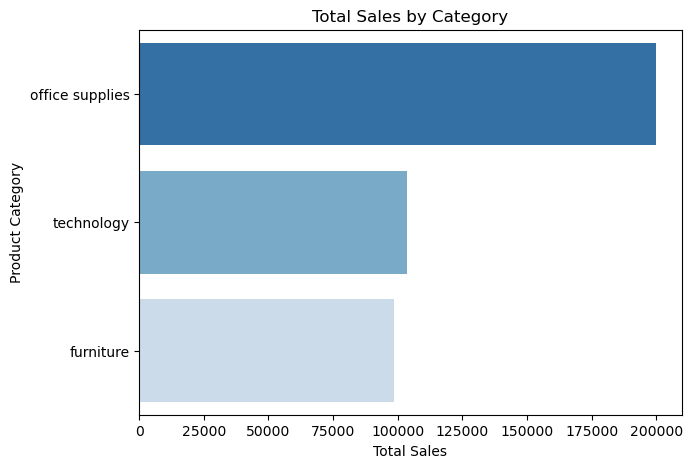

In [38]:
# Aggregate total sales by category
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x=category_sales.values, y=category_sales.index, hue=category_sales.index, palette="Blues_r", legend=False)
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.title("Total Sales by Category")
plt.show()


## Visualization 10: Average Profit Per Order By Product Category

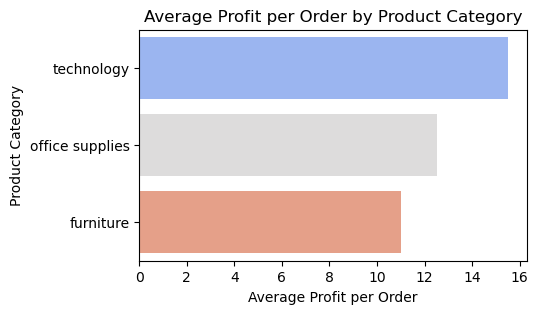

In [39]:
# Compute average profit per category
category_avg_profit = df.groupby("category")["profit"].mean().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(5, 3))
sns.barplot(x=category_avg_profit.values, y=category_avg_profit.index, hue=category_avg_profit.index, palette="coolwarm", legend=False)
plt.xlabel("Average Profit per Order")
plt.ylabel("Product Category")
plt.title("Average Profit per Order by Product Category")
plt.show()

## Visualization 11: Total Sales Per Month

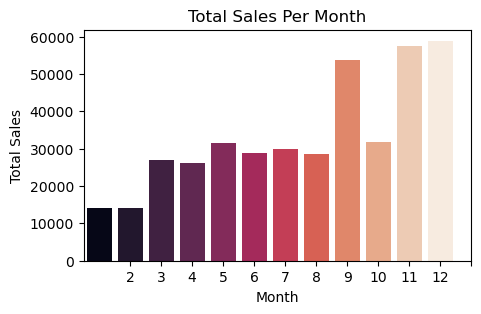

In [40]:
df["month"] = pd.to_datetime(df["order_date"]).dt.month
# Compute total sales per month
monthly_sales = df.groupby("month")["sales"].sum()

# Plot bar chart
plt.figure(figsize=(5, 3))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, hue=monthly_sales.index, palette="rocket", legend=False)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Total Sales Per Month")
plt.xticks(range(1, 13))
plt.show()

## Visualization 12: Total Sales by Manufacturer

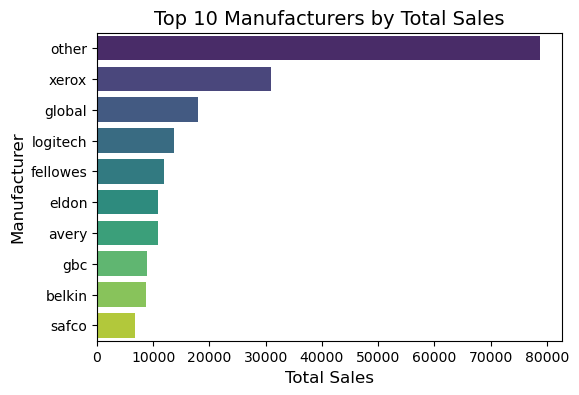

In [41]:
# Compute total sales per manufacturer
manufacturer_sales = df.groupby("manufactory")["sales"].sum().sort_values(ascending=False)

# Select only the top 10 manufacturers
top_manufacturers = manufacturer_sales.head(10)

# Plot bar chart
plt.figure(figsize=(6, 4))
sns.barplot(y=top_manufacturers.index, x=top_manufacturers.values, hue=top_manufacturers.index, palette="viridis", legend=False)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Manufacturer", fontsize=12)
plt.title("Top 10 Manufacturers by Total Sales", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)  # Ensure manufacturer names are readable
plt.show()

## Visualization 13: Number of Orders Shipped Per Month

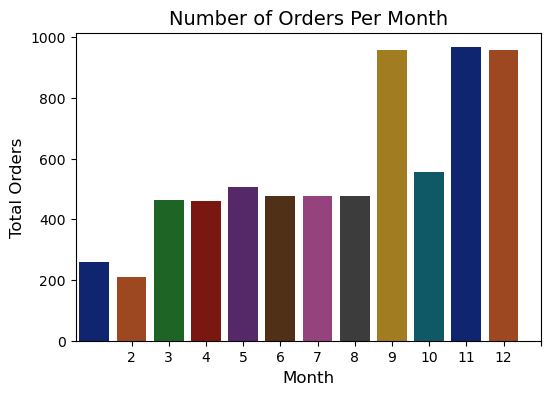

In [42]:
orders_per_month = df.groupby("month")["order_id"].count()

# Plot number of orders per month
plt.figure(figsize=(6, 4))
sns.barplot(x=orders_per_month.index, y=orders_per_month.values, hue=orders_per_month.index, palette="dark", legend=False)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.title("Number of Orders Per Month", fontsize=14)
plt.xticks(range(1, 13), fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Visualization 14: Sales VS Profits 

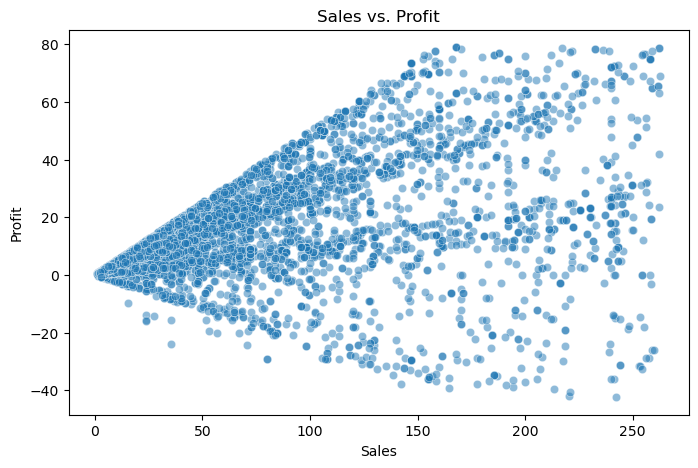

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["sales"], y=df["profit"], alpha=0.5)
plt.title("Sales vs. Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()


#  Visualizing Outliers Using Boxplots

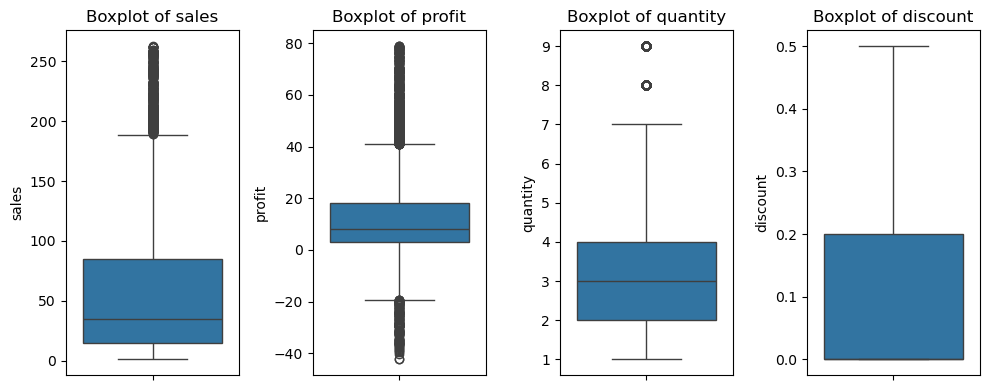

In [44]:
# Visualizing outliers in numerical columns
plt.figure(figsize=(10, 4))

# Selecting numerical columns to check for outliers
numerical_cols = ['sales', 'profit', 'quantity', 'discount']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 4, i)  # Create subplots
    sns.boxplot(y=df[col])  # Create boxplot
    plt.title(f'Boxplot of {col}')

plt.tight_layout() 
plt.show()


##  Feature Engineering & Data Encoding
To enhance our analysis, we create new features such as:
- Shipping time calculation
- Extracting the year and month from order dates
- One-hot encoding categorical variables for better machine learning performance

These transformations help in identifying trends and improving model accuracy.


#  Applying Min-Max Scaling to Key Columns

In [45]:
from sklearn.preprocessing import MinMaxScaler

# Selecting numerical columns to scale
columns_to_scale = ['sales', 'profit', 'quantity']

# Applying Min-Max Scaling
scaler = MinMaxScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Checking the transformed values
df.head()


,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,...,state,discount,profit,quantity,sales,profit_margin,shipping_time,year,month,ship_month
0,US-2020-103800,2019-01-03,2019-01-07,darren powers,message book,"message book, wirebound, four 5 1/2"" x 4"" form...",consumer,office supplies,paper,central,...,texas,0.2,0.395234,0.125,0.059028,0.3375,4,2019,1,1
2,US-2020-112326,2019-01-04,2019-01-08,phillina ober,avery,avery 508,home office,office supplies,labels,central,...,illinois,0.2,0.384691,0.250,0.041218,0.3625,4,2019,1,1
4,US-2020-141817,2019-01-05,2019-01-12,mick brown,avery,avery hi-liter everbold pen style fluorescent ...,consumer,office supplies,art,east,...,pennsylvania,0.2,0.389736,0.250,0.070820,0.2500,7,2019,1,1
5,US-2020-106054,2019-01-06,2019-01-07,jack o'briant,dixon,"dixon prang watercolor pencils, 10-color set w...",corporate,office supplies,art,south,...,georgia,0.0,0.392668,0.250,0.045022,0.4100,1,2019,1,1
6,US-2020-130813,2019-01-06,2019-01-08,lycoris saunders,xerox,xerox 225,consumer,office supplies,paper,west,...,california,0.0,0.426383,0.250,0.070454,0.4800,2,2019,1,1


# Encoding Categorical Variables

In [46]:
# Perform One-Hot Encoding on categorical columns
categorical_columns = ['category', 'subcategory', 'region', 'segment']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Display new column names
df.head()


,order_id,order_date,ship_date,customer,manufactory,product_name,city,state,discount,profit,...,subcategory_paper,subcategory_phones,subcategory_storage,subcategory_supplies,subcategory_tables,region_east,region_south,region_west,segment_corporate,segment_home office
0,US-2020-103800,2019-01-03,2019-01-07,darren powers,message book,"message book, wirebound, four 5 1/2"" x 4"" form...",houston,texas,0.2,0.395234,...,True,False,False,False,False,False,False,False,False,False
2,US-2020-112326,2019-01-04,2019-01-08,phillina ober,avery,avery 508,naperville,illinois,0.2,0.384691,...,False,False,False,False,False,False,False,False,False,True
4,US-2020-141817,2019-01-05,2019-01-12,mick brown,avery,avery hi-liter everbold pen style fluorescent ...,philadelphia,pennsylvania,0.2,0.389736,...,False,False,False,False,False,True,False,False,False,False
5,US-2020-106054,2019-01-06,2019-01-07,jack o'briant,dixon,"dixon prang watercolor pencils, 10-color set w...",athens,georgia,0.0,0.392668,...,False,False,False,False,False,False,True,False,True,False
6,US-2020-130813,2019-01-06,2019-01-08,lycoris saunders,xerox,xerox 225,los angeles,california,0.0,0.426383,...,True,False,False,False,False,False,False,True,False,False


# Encoding Ordinal Data

In [47]:
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder
# Create an instance of LabelEncoder
le = LabelEncoder()
# Apply label encoding to the 'state' column
df['state'] = le.fit_transform(df['state'])
# Checking encoded values
df[['state']].head()


,state
0,41
2,11
4,36
5,9
6,3


# Aggregating Data 
### - Total Sales & Orders Per Year 
### - Total Orders Per Year
### - Average Profit Per Category

In [48]:
df['order_year'] = df['order_date'].dt.year

# Aggregating total sales per year
sales_per_year = df.groupby('order_year')['sales'].sum().reset_index()

# Display sales per year
sales_per_year


,order_year,sales
0,2019,287.606312
1,2020,318.584533
2,2021,388.033677
3,2022,515.469414


In [49]:
orders_per_year = df.groupby("year")["order_id"].nunique().reset_index()
orders_per_year

,year,order_id
0,2019,781
1,2020,845
2,2021,1057
3,2022,1368


In [50]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days
avg_shipping_time = df['shipping_time'].mean()

console = Console()
styled_text = Text(f"Average Shipping Time: {avg_shipping_time:.2f} days", style="bold green")


console.print(styled_text)


Average Shipping Time: 3.96 days

In [51]:
from rich.console import Console  # Import Console for styled output
from rich.table import Table  # Import Table for displaying formatted tables
# Ensure column names are lowercase and stripped
df.columns = df.columns.str.lower().str.strip()

# Identify category columns (they start with 'category_')
category_columns = [col for col in df.columns if col.startswith('category_')]
# Melt the DataFrame to reshape it
df_melted = df.melt(id_vars=['profit'], value_vars=category_columns, var_name='category', value_name='is_category')
# Filter only rows where 'is_category' == 1 (i.e., the row belongs to that category)
df_melted = df_melted[df_melted['is_category'] == 1]
df_melted['category'] = df_melted['category'].str.replace('category_', '', regex=False)
# Calculate average profit per category
category_avg_profit = df_melted.groupby("category")["profit"].mean().sort_values(ascending=False)

console = Console()
# Create styled table
table = Table(title="Average Profit per Category", show_header=True, header_style="bold magenta")
table.add_column("Category", style="cyan", justify="left")
table.add_column("Average Profit", style="green", justify="right")
# Add data to the table
for category, profit in category_avg_profit.items():
    table.add_row(category, f"${profit:,.2f}")

console.print(table)


    Average Profit per Category     
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Category        ┃ Average Profit ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ technology      │          $0.48 │
│ office supplies │          $0.45 │
└─────────────────┴────────────────┘

In [52]:
from rich.console import Console  
from rich.table import Table  

# Ensure column names are lowercase and stripped
df.columns = df.columns.str.lower().str.strip()

# Identify category columns (they start with 'category_')
category_columns = [col for col in df.columns if col.startswith('category_')]
# Convert one-hot encoded category columns back to a single "category" column
df['category'] = df[category_columns].idxmax(axis=1).str.replace('category_', '', regex=False)
# Group by category and calculate total sales
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)
# Initialize Console
console = Console()

# Create styled table
table = Table(title="Total Sales per Category", show_header=True, header_style="bold magenta")
table.add_column("Category", style="cyan", justify="left")
table.add_column("Total Sales", style="green", justify="right")
# Add data to the table
for category, sales in category_sales.items():
    table.add_row(category, f"${sales:,.2f}")

console.print(table)


    Total Sales per Category     
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Category        ┃ Total Sales ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ office supplies │   $1,118.30 │
│ technology      │     $391.39 │
└─────────────────┴─────────────┘

In [53]:
from rich.console import Console  
from rich.table import Table 

# Ensure column names are lowercase and stripped
df.columns = df.columns.str.lower().str.strip()

# Check if required columns exist before proceeding
if "category" in df.columns and "profit" in df.columns:
    # Calculate the average profit per category
    category_avg_profit = df.groupby("category")["profit"].mean().sort_values(ascending=False)
  # Initialize Console for styled output
    console = Console()

    # Create a styled table for output
    table = Table(title=" Average Profit per Category", show_header=True, header_style="bold magenta")
    table.add_column("Category", style="cyan", justify="left")
    table.add_column("Average Profit", style="green", justify="right")
# Add data to the table
    for category, profit in category_avg_profit.items():
        table.add_row(category, f"${profit:,.2f}")
 # Print the table
    console.print(table)
else:
    print("[ERROR]  'category' or 'profit' column is missing from the DataFrame.")


     Average Profit per Category    
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Category        ┃ Average Profit ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ technology      │          $0.48 │
│ office supplies │          $0.45 │
└─────────────────┴────────────────┘

## Conclusion

The analysis shows how sales, profit, discounting, shipping time, customer behavior, product categories, and manufacturer performance can be examined from transactional Superstore data. Key findings include:

- Technology had the highest average profit per order in the cleaned dataset.
- A measurable share of orders produced negative profit, highlighting the importance of discount and margin analysis.
- December generated the highest monthly sales total in the analyzed period.
- Order volume increased year over year from 2019 through 2022.
- Feature engineering steps such as shipping-time extraction, min-max scaling, one-hot encoding, and label encoding prepared the dataset for future machine learning workflows.

These insights can support better decisions around pricing, product focus, shipping operations, and customer segmentation.


In [54]:
print(df[['order_date', 'ship_date']].dtypes)


order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


In [55]:
category_sales = df.groupby("category")["sales"].sum().sort_values()
print(category_sales)


category
technology          391.392876
office supplies    1118.301059
Name: sales, dtype: float64
